In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import sunpy.visualization.colormaps as sunpycm
from loguru import logger as lgr_logger
from omegaconf import OmegaConf

from sdofmv2.core import MAE, SDOMLDataModule
from sdofmv2.utils import ALL_WAVELENGTHS

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = OmegaConf.load(
    "../../configs/pretrain/pretrain_mae_AIA.yaml"
    )

In [3]:
data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    frequency=cfg.data.sdoml.frequency,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    val_months=cfg.data.month_splits.val,
    test_months=cfg.data.month_splits.test,
    holdout_months=cfg.data.month_splits.holdout,
    cache_dir=os.path.join(
        "../../assets",
        cfg.data.sdoml.sub_directory.cache,
    ),
    min_date=cfg.data.min_date,
    max_date=cfg.data.max_date,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
)
data_module.setup()


# data_module_for_old = SDOMLDataModule(
#     hmi_path=os.path.join(
#         cfg_old.data.sdoml.base_directory, 
#         cfg_old.data.sdoml.sub_directory.hmi
#     ) if cfg_old.data.sdoml.sub_directory.hmi else None,
#     aia_path=os.path.join(
#         cfg_old.data.sdoml.base_directory,
#         cfg_old.data.sdoml.sub_directory.aia,
#     ) if cfg_old.data.sdoml.sub_directory.aia else None,
#     eve_path=None,
#     components=cfg_old.data.sdoml.components,
#     wavelengths=cfg_old.data.sdoml.wavelengths,
#     ions=cfg_old.data.sdoml.ions,
#     frequency=cfg_old.data.sdoml.frequency,
#     batch_size=cfg_old.model.opt.batch_size,
#     num_workers=cfg_old.data.num_workers,
#     val_months=cfg_old.data.month_splits.val,
#     test_months=cfg_old.data.month_splits.test,
#     holdout_months=cfg_old.data.month_splits.holdout,
#     cache_dir=os.path.join(
#         "../assets",
#         cfg_old.data.sdoml.sub_directory.cache,
#     ),
#     min_date=cfg_old.data.min_date,
#     max_date=cfg_old.data.max_date,
#     num_frames=cfg_old.model.mae.num_frames,
#     drop_frame_dim=cfg_old.data.drop_frame_dim,
#     apply_mask=cfg_old.data.sdoml.apply_mask,
#     precision=cfg_old.experiment.precision,
#     normalization=cfg_old.data.sdoml.normalization,
# )
# data_module_for_old.setup()

[* CACHE SYSTEM *] Found cached index data in ../../assets/cache/aligndata_AIA_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-03-09 01:59:48.832 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/131A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:59:48.833 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/1600A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:59:48.834 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/1700A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:59:48.834 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/171A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:59:48.835 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/193A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:59:48.836 | INFO     | sdofmv2.core.datamodu

[* CACHE SYSTEM *] Found cached HMI mask data in ../../assets/cache/hmi_mask_512x512.npy.


In [4]:
wavelenghs = ALL_WAVELENGTHS
wavelenghs.sort()

wave_val_list = []
for wave in wavelenghs:
    val = wave[:-1]
    wave_val_list.append(int(val))

wave_arr = np.array(wave_val_list)
sort_ids = np.argsort(wave_arr)

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
]

In [5]:
ckpt_dir = "../../assets/check_point/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "AIA/id_6lfzuk01_mae_epoch=76-val_loss=0.00.ckpt", 
    map_location="cpu",
    weights_only=False)
lgr_logger.info(f"masking ratio of sdofmv2: {model.masking_ratio}")

2026-03-09 02:00:15.281 | INFO     | __main__:<module>:6 - masking ratio of sdofmv2: 0.5


In [6]:
# timestamps = ["2010-06-16 00:00:00"]
timestamps = [
    "2011-12-25 00:12:00",
    # "2012-12-25 00:12:00",
    # "2013-12-25 00:12:00",
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]
print(f"Datetime: {ts}")

Datetime: [Timestamp('2011-12-25 00:12:00')]


In [7]:
model.eval()

with torch.no_grad():
    output = model(x_set, mask_ratio=0.5)

In [8]:
patch_size = 16
# visualize masking
mask_grid = output[1][0].reshape(512 // patch_size, 512 // patch_size)
mask_full = np.kron(mask_grid, np.ones((patch_size, patch_size)))
mask_full = torch.tensor(mask_full, dtype=bool)

In [16]:
# # norm information
# norm_stat = {"AIA": {}}
# norm_stat_old = {"AIA": {}}
# for ch_id, ch in enumerate(wavelenghs):
    
#     cache_path = "../assets/cache/AIA/"
#     file_name = (
#         ch
#         + "_"
#         + "_".join(data_module.cache_id.split("_")[-1:])
#         + f"_norm-{data_module.normalization.type}"
#         + ".json"
#     )
#     file_name_old = (
#         ch
#         + "_"
#         + "_".join(data_module_for_old.cache_id.split("_")[-1:])
#         + f"_norm-{data_module_for_old.normalization.type}"
#         + ".json"
#     )

#     with open(cache_path + file_name, "r") as json_file:
#         ch_stat = json.load(json_file)
    
#     with open(cache_path + file_name_old, "r") as json_file:
#         ch_stat_old = json.load(json_file)


#     norm_stat["AIA"][ch] = ch_stat
#     norm_stat_old["AIA"][ch] = ch_stat_old


# # input/output inverse log transform for visualization
# for img_id in range(x_set.shape[0]):
#     for ch_id, ch in enumerate(wavelenghs):

#         output[0][img_id, ch_id, 0, :, :] = inverse_log_norm(
#             output[0][img_id, ch_id, 0, :, :],
#             norm_stat,
#             "AIA",
#             ch,
#             cfg.data.sdoml.normalization.scaler_factor,
#             cfg.data.sdoml.normalization.scaler_div_factor
#         )

#         x_set[img_id, ch_id, 0, :, :] = inverse_log_norm(
#             x_set[img_id, ch_id, 0, :, :],
#             norm_stat,
#             "AIA",
#             ch,
#             cfg.data.sdoml.normalization.scaler_factor,
#             cfg.data.sdoml.normalization.scaler_div_factor
#         )

/tmp/ipykernel_1226620/3617178311.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_1226620/3617178311.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()
/tmp/ipykernel_1226620/3617178311.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


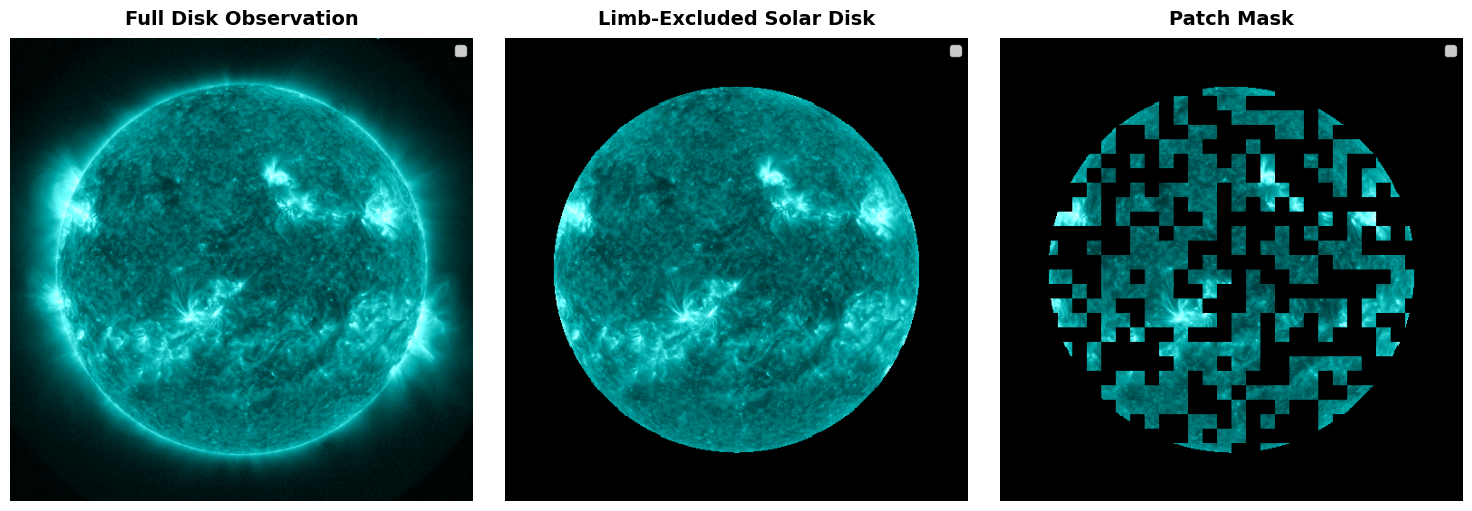

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].imshow(x_set[0, 0, 0, :, :], cmap=cms[0])
axes[0].set_title('Full Disk Observation', fontsize=14, weight="bold", pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].legend()

axes[1].imshow(x_set[0, 0, 0, :, :] * model.limb_mask, cmap=cms[0])
axes[1].set_title('Limb-Excluded Solar Disk', fontsize=14, weight="bold", pad=10)
axes[1].set_xlabel('')
axes[1].legend()

axes[2].imshow(x_set[0, 0, 0, :, :] * model.limb_mask* mask_full, cmap=cms[0])
axes[2].set_title('Patch Mask', fontsize=14, weight="bold", pad=10)
# axes[2].set_xlabel('')
axes[2].legend()

plt.tight_layout()

plt.savefig('limb_mask_example.pdf', dpi=300, bbox_inches="tight")
plt.show()